In [123]:
import pandas as pd
import numpy as np
from scipy.interpolate import interp1d
from scipy.special import erf
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8")

fontsize = 15
plt.rcParams.update(
    {
        "font.family": "serif",
        "font.size": fontsize,
        "axes.labelsize": fontsize,
        "axes.titlesize": fontsize,
        "xtick.labelsize": fontsize,
        "ytick.labelsize": fontsize,
        "legend.fontsize": fontsize,
        "mathtext.default": "regular",
        "mathtext.fontset": "cm",
        "legend.frameon": True,
    }
)


ruta = "../datos/barrido_perfil.csv"

def modified_erf(x, mean, std_dev, amplitude):
    """
    Integral of a Gaussian from x to infinity.

    Gaussian:
        f(x) = amplitude * exp(-(x - mean)^2 / (2 * std_dev^2))
    """
    x = np.asarray(x)

    return amplitude * std_dev * np.sqrt(np.pi / 2) * (1 - erf((x - mean) / (std_dev * np.sqrt(2))))

col_names = [
    "pos_con",  "I_con",  "err_con",  "sep1",
    "pos_sin",  "I_sin",  "err_sin",  "sep2",
    "extra",
]

df_raw = pd.read_csv(
    ruta,
    skiprows=2,          
    header=None,
    names=col_names,
    usecols=range(len(col_names)),
)

df1 = df_raw[["pos_con", "I_con", "err_con"]].apply(pd.to_numeric, errors="coerce").dropna().reset_index(drop=True)
df2 = df_raw[["pos_sin", "I_sin", "err_sin"]].apply(pd.to_numeric, errors="coerce").dropna().reset_index(drop=True)
df1["pos_con"] = df1["pos_con"] / 100 # Pasar de 10 mu m a mm
df2["pos_sin"] = df2["pos_sin"] / 100

Parámetros ajustados: mean = 13.10, std_dev = 0.18, amplitude = 239.23


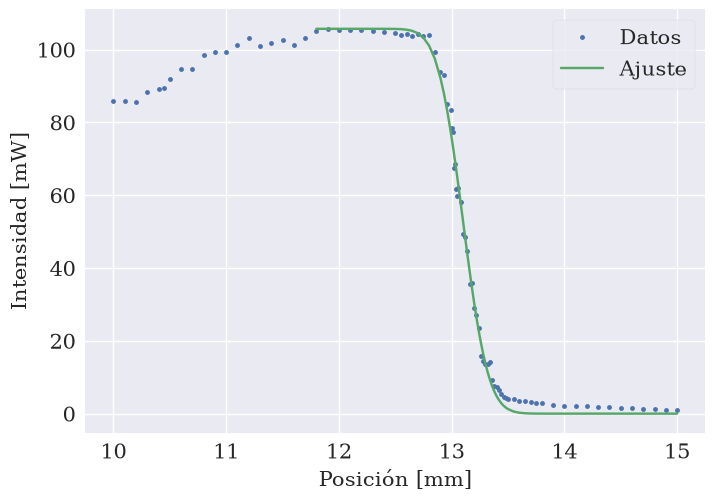

In [126]:
interp_sin = interp1d(
    df2["pos_sin"], df2["I_sin"],
    kind="linear",
    bounds_error=False,
    fill_value=np.nan,  
)

I_sin_interp_en_pos_con = interp_sin(df1["pos_con"])
sin_background = df1["I_con"].to_numpy() - I_sin_interp_en_pos_con
posiciones = df1["pos_con"].to_numpy()

rango = posiciones>=11.8
popt, pcov = curve_fit(modified_erf, posiciones[rango], sin_background[rango], p0 = (13,0.23,1.7))
plt.plot(posiciones, sin_background, ".", label="Datos")
plt.plot(posiciones[rango], modified_erf(posiciones[rango], *popt), label="Ajuste")
plt.legend()
plt.xlabel("Posición [mm]")
plt.ylabel("Intensidad [mW]")
print("Parámetros ajustados: mean = {:.2f}, std_dev = {:.2f}, amplitude = {:.2f}".format(*popt))